### Pacotes importados

In [16]:
# codigo aqui

## Chapter 11: Descent methods and line search

### Algorithm 11.2: Initialization of the exact line search 

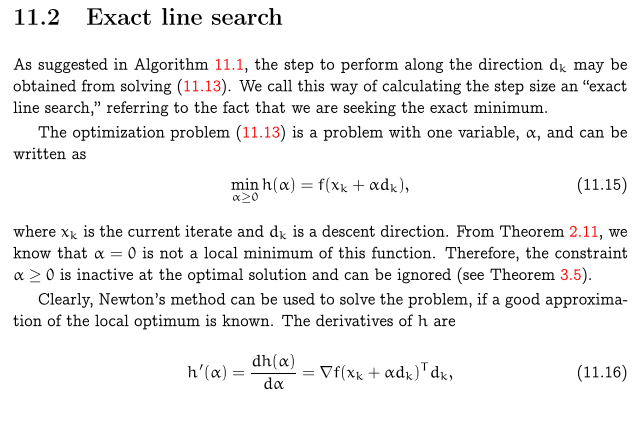

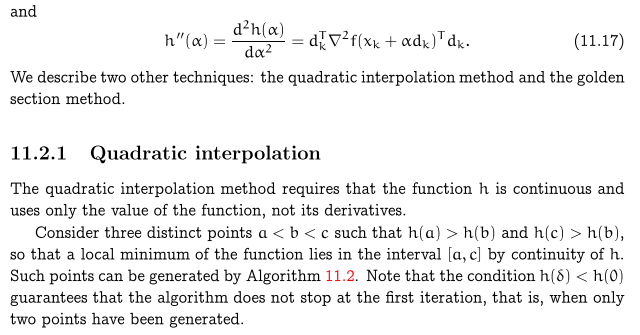

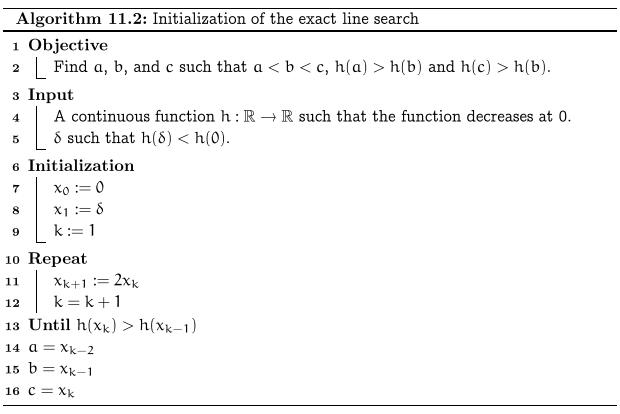

Test with Example 11.3: $h(x) = (2+x) \cos(2+x)$.

In [17]:
# Algoritmo 11.2 - Inicialização da Busca de Linha Exata
# Objetivo: encontrar a, b, c tais que a < b < c, h(a) > h(b) e h(c) > h(b)
# Exemplo 11.3: h(x) = (2 + x)·cos(2 + x)

using Printf
using Plots

# ── Função ────────────────────────────────────────────────────────────────
h(x) = (2 + x) * cos(2 + x)

# ── Parâmetros ────────────────────────────────────────────────────────────
δ = 0.1          # h(δ) < h(0) — função decresce em 0

# Verificar condição inicial
println("=== Algoritmo 11.2 — Inicialização da Busca de Linha Exata ===")
println("h(x) = (2 + x)·cos(2 + x)\n")
@printf("h(0) = %+.8E\n", h(0.0))
@printf("h(δ) = h(%.1f) = %+.8E\n", δ, h(δ))
println("h(δ) < h(0)? ", h(δ) < h(0.0) ? "✓ SIM — condição satisfeita" :
                                           "✗ NÃO — escolha outro δ")

# ── Inicialização (linhas 7-9) ────────────────────────────────────────────
x_prev  = 0.0    # x₀ := 0
x_curr  = δ      # x₁ := δ
k       = 1

println("\nk \t xk \t\t\t h(xk) \t\t\t h(xk) > h(xk-1)?")
@printf("0 \t %+.8E \t %+.8E \t ---\n", x_prev, h(x_prev))
@printf("1 \t %+.8E \t %+.8E \t %s\n",
        x_curr, h(x_curr), h(x_curr) > h(x_prev) ? "✓ SIM → PARA" : "NÃO → continua")

# ── Loop principal (linhas 10-12) ─────────────────────────────────────────
while h(x_curr) <= h(x_prev)
    x_next = 2 * x_curr     # x_{k+1} := 2·xk
    k += 1
    @printf("%d \t %+.8E \t %+.8E \t %s\n",
            x_next, h(x_next),
            h(x_next) > h(x_curr) ? "✓ SIM → PARA" : "NÃO → continua")
    x_prev = x_curr
    x_curr = x_next
end

# ── Resultado (linhas 14-16) ──────────────────────────────────────────────
a = x_prev / 2     # x_{k-2}
b = x_prev         # x_{k-1}
c = x_curr         # x_k

println("\n=== Resultado ===")
@printf("a = x_{k-2} = %+.8E,  h(a) = %+.8E\n", a, h(a))
@printf("b = x_{k-1} = %+.8E,  h(b) = %+.8E\n", b, h(b))
@printf("c = x_k     = %+.8E,  h(c) = %+.8E\n", c, h(c))
println()
println("Verificação das condições:")
println("  a < b < c ?    ", a < b < c   ? "✓ SIM" : "✗ NÃO")
println("  h(a) > h(b) ?  ", h(a) > h(b) ? "✓ SIM" : "✗ NÃO")
println("  h(c) > h(b) ?  ", h(c) > h(b) ? "✓ SIM" : "✗ NÃO")

# ── Gráfico ───────────────────────────────────────────────────────────────
xs = range(-0.1, c + 0.2, length=500)
plot(xs, h.(xs),
    label      = "h(x) = (2+x)cos(2+x)",
    xlabel     = "x",
    ylabel     = "h(x)",
    title      = "Algoritmo 11.2 — Inicialização da Busca de Linha",
    legend     = :topright,
    linewidth  = 2)

scatter!([a, b, c], [h(a), h(b), h(c)],
    label  = ["a" "b" "c"],
    marker = [:square :circle :diamond],
    color  = [:red :green :blue],
    ms     = 8)

vline!([a, b, c], linestyle = :dash, alpha = 0.4, label = "")
annotate!(a, h(a) + 0.05, "a")
annotate!(b, h(b) - 0.08, "b")
annotate!(c, h(c) + 0.05, "c")

=== Algoritmo 11.2 — Inicialização da Busca de Linha Exata ===
h(x) = (2 + x)·cos(2 + x)

h(0) = -8.32293673E-01
h(δ) = h(0.1) = -1.06017682E+00
h(δ) < h(0)? ✓ SIM — condição satisfeita

k 	 xk 			 h(xk) 			 h(xk) > h(xk-1)?
0 	 +0.00000000E+00 	 -8.32293673E-01 	 ---
1 	 +1.00000000E-01 	 -1.06017682E+00 	 NÃO → continua


ArgumentError: ArgumentError: Number of format specifiers and number of provided args differ: 4 != 3

### Algorithm 11.3: Exact line search: quadratic interpolation

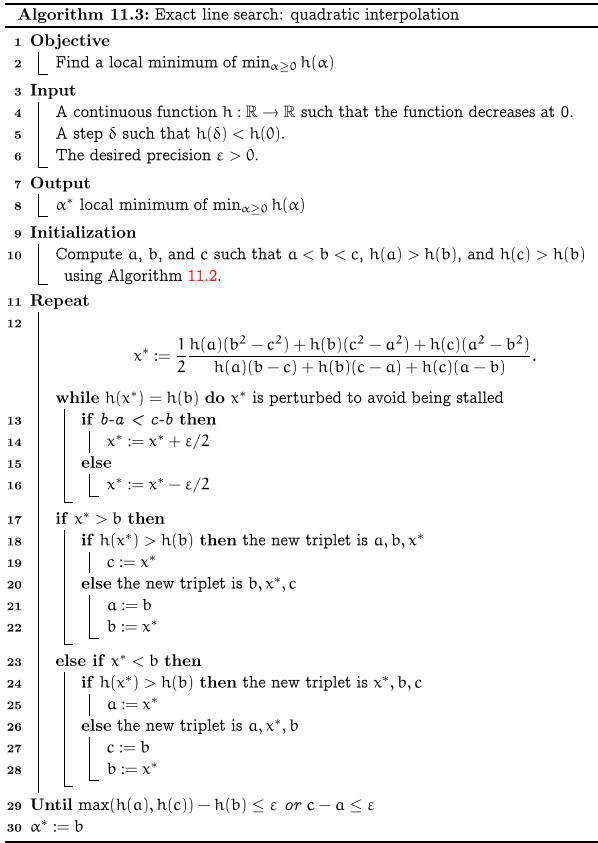

Test with Example 11.3: $h(x) = (2+x) \cos(2+x)$.

=== Algoritmo 11.3 — Interpolação Quadrática ===
h(x) = (2+x)·cos(2+x),  δ = 0.1,  ε = 1.0e-10

Inicialização (Alg. 11.2):
  a = +8.00000000E-01,  h(a) = -2.63822255E+00
  b = +1.60000000E+00,  h(b) = -3.22833030E+00
  c = +3.20000000E+00,  h(c) = +2.43628669E+00

k 	 a 			 b 			 c 			 x* 			 h(x*) 			 c-a
0 	 +8.000000E-01 	 +1.600000E+00 	 +3.200000E+00 	 +1.406909E+00 	 -3.287700E+00 	 +2.400000E+00
1 	 +8.000000E-01 	 +1.406909E+00 	 +1.600000E+00 	 +1.414178E+00 	 -3.288120E+00 	 +8.000000E-01
2 	 +1.406909E+00 	 +1.414178E+00 	 +1.600000E+00 	 +1.425245E+00 	 -3.288371E+00 	 +1.930908E-01
3 	 +1.414178E+00 	 +1.425245E+00 	 +1.600000E+00 	 +1.425468E+00 	 -3.288371E+00 	 +1.858218E-01
4 	 +1.425245E+00 	 +1.425468E+00 	 +1.600000E+00 	 +1.425612E+00 	 -3.288371E+00 	 +1.747552E-01
5 	 +1.425468E+00 	 +1.425612E+00 	 +1.600000E+00 	 +1.425616E+00 	 -3.288371E+00 	 +1.745323E-01
6 	 +1.425612E+00 	 +1.425616E+00 	 +1.600000E+00 	 +1.425618E+00 	 -3.288371E+00 	 +1.743882E-01
7 	 +1

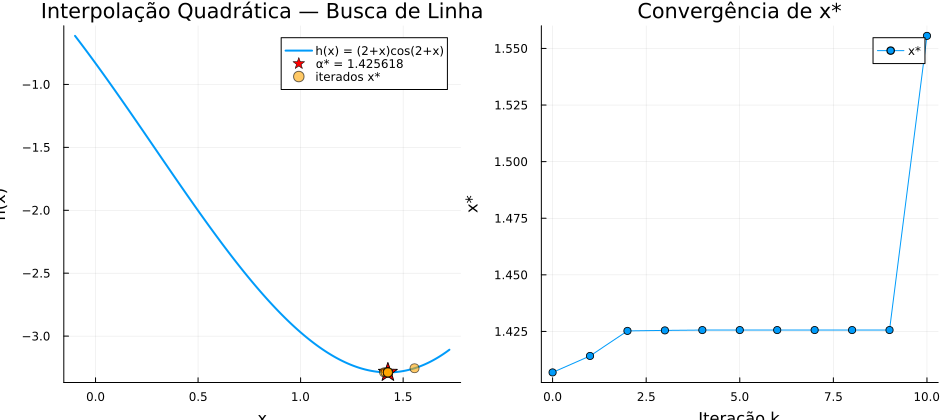

In [18]:
# Algoritmo 11.3 - Busca de Linha Exata: Interpolação Quadrática
# h(x) = (2 + x)·cos(2 + x), δ = 0.1, ε = 1e-10

using Printf
using Plots

# ── Função ────────────────────────────────────────────────────────────────
h(x) = (2 + x) * cos(2 + x)

# ── Algoritmo 11.2 (inicialização) ───────────────────────────────────────
function inicializar(h, δ)
    x_prev = 0.0
    x_curr = δ
    while h(x_curr) <= h(x_prev)
        x_next = 2 * x_curr
        x_prev = x_curr
        x_curr = x_next
    end
    a = x_prev / 2
    b = x_prev
    c = x_curr
    return a, b, c
end

# ── Fórmula do mínimo da parábola interpolante ────────────────────────────
function interpolar(a, b, c, h)
    num = h(a)*(b^2 - c^2) + h(b)*(c^2 - a^2) + h(c)*(a^2 - b^2)
    den = h(a)*(b - c)     + h(b)*(c - a)     + h(c)*(a - b)
    return 0.5 * num / den
end

# ── Parâmetros ────────────────────────────────────────────────────────────
δ = 0.1
ε = 1e-10

# Inicialização via Alg. 11.2
a, b, c = inicializar(h, δ)

println("=== Algoritmo 11.3 — Interpolação Quadrática ===")
println("h(x) = (2+x)·cos(2+x),  δ = $δ,  ε = $ε\n")
println("Inicialização (Alg. 11.2):")
@printf("  a = %+.8E,  h(a) = %+.8E\n", a, h(a))
@printf("  b = %+.8E,  h(b) = %+.8E\n", b, h(b))
@printf("  c = %+.8E,  h(c) = %+.8E\n", c, h(c))
println()
println("k \t a \t\t\t b \t\t\t c \t\t\t x* \t\t\t h(x*) \t\t\t c-a")

k = 0
xs_hist = Float64[]   # histórico de x* para o gráfico

# ── Loop principal ────────────────────────────────────────────────────────
while true

    # Passo 12: calcular x* pela fórmula da parábola
    xs = interpolar(a, b, c, h)

    # Perturbação se h(x*) == h(b) (evitar travamento)
    if h(xs) ≈ h(b)
        xs = (b - a < c - b) ? xs + ε/2 : xs - ε/2
    end

    push!(xs_hist, xs)
    @printf("%d \t %+.6E \t %+.6E \t %+.6E \t %+.6E \t %+.6E \t %+.6E\n",
            k, a, b, c, xs, h(xs), c - a)

    # Condição de parada (linha 29)
    if max(h(a), h(c)) - h(b) <= ε || c - a <= ε
        break
    end

    # Atualização do triplete (linhas 17-28)
    if xs > b
        if h(xs) > h(b)
            c = xs              # novo triplete: a, b, x*
        else
            a = b               # novo triplete: b, x*, c
            b = xs
        end
    elseif xs < b
        if h(xs) > h(b)
            a = xs              # novo triplete: x*, b, c
        else
            c = b               # novo triplete: a, x*, b
            b = xs
        end
    end

    k += 1
end

println("\n=== Resultado ===")
@printf("α* = b = %+.8E\n", b)
@printf("h(α*) = %+.8E\n", h(b))
@printf("Convergiu em %d iterações\n", k)

# ── Gráfico ───────────────────────────────────────────────────────────────
xs_plot = range(-0.1, c + 0.3, length=500)

p1 = plot(xs_plot, h.(xs_plot),
    label     = "h(x) = (2+x)cos(2+x)",
    xlabel    = "x", ylabel = "h(x)",
    title     = "Interpolação Quadrática — Busca de Linha",
    linewidth = 2, legend = :topright)

scatter!([b], [h(b)],
    label  = "α* = $( round(b, digits=6))",
    marker = :star5, ms = 10, color = :red)

scatter!(xs_hist, h.(xs_hist),
    label  = "iterados x*",
    marker = :circle, ms = 5, color = :orange, alpha = 0.6)

p2 = plot(0:k, xs_hist,
    seriestype = :line,
    marker     = :circle,
    xlabel     = "Iteração k",
    ylabel     = "x*",
    title      = "Convergência de x*",
    label      = "x*",
    legend     = :topright)

plot(p1, p2, layout = (1,2), size = (950, 420))

### Algorithm 11.5: Line search

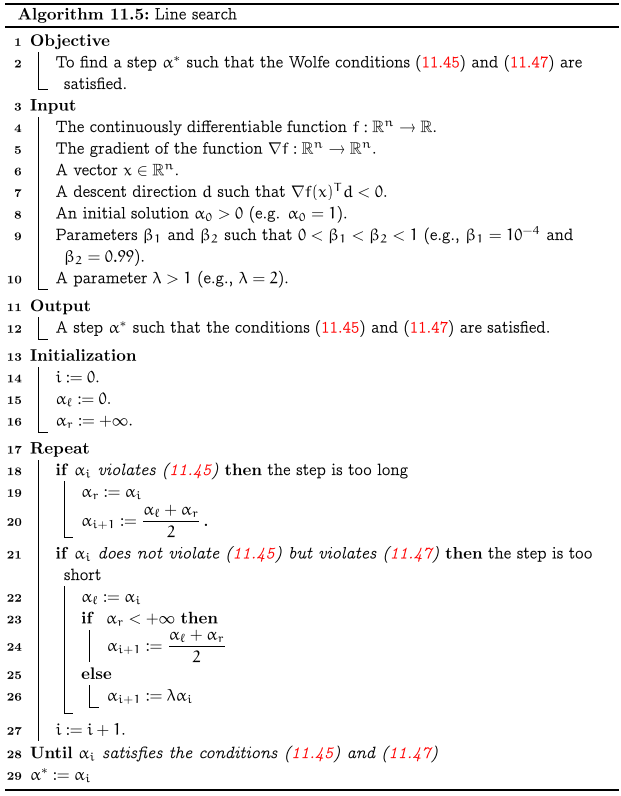

Example 11.2: $f(x) = \frac{1}{2} x_1^2 + \frac{9}{2} x_2^2$.

=== Algoritmo 11.5 — Line Search (Condições de Wolfe) ===
f(x) = (1/2)x1² + (9/2)x2²
x    = [1.0, 1.0]
d    = [-1.0, -9.0]  (gradiente negativo)
f(x) = +5.00000000E+00
∇f(x)ᵀd = -8.20000000E+01  (< 0 ✓)

Parâmetros: α₀=1, β₁=1e-4, β₂=0.99, λ=2

i 	 αi 			 αl 			 αr 			 Armijo 	 Curvatura
0 	 +1.00000000E+00 	 +0.00000000E+00 	       +Inf      	 ✗ viola 	 ✓ ok   
1 	 +5.00000000E-01 	 +0.00000000E+00 	 +1.00000000E+00 	 ✗ viola 	 ✓ ok   
2 	 +2.50000000E-01 	 +0.00000000E+00 	 +5.00000000E-01 	 ✗ viola 	 ✓ ok   
3 	 +1.25000000E-01 	 +0.00000000E+00 	 +2.50000000E-01 	 ✓ ok    	 ✓ ok   

✓ Ambas as condições de Wolfe satisfeitas!

α* = +1.25000000E-01
x + α*·d = [+8.75000000E-01, -1.25000000E-01]
f(x + α*·d) = +4.53125000E-01
Convergiu em 3 iterações


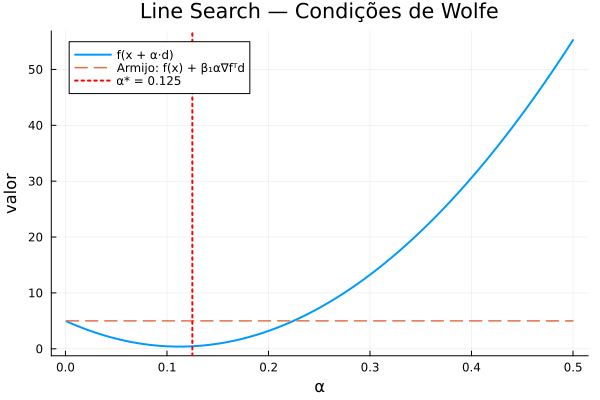

In [19]:
# Algoritmo 11.5 - Line Search (Condições de Wolfe)
# f(x1, x2) = (1/2)x1² + (9/2)x2²
# x e d a serem definidos para o teste

using Printf
using LinearAlgebra
using Plots

# ── Funções ───────────────────────────────────────────────────────────────
f(x)  = 0.5*x[1]^2 + 4.5*x[2]^2

function ∇f(x)
    return [x[1], 9.0*x[2]]
end

# ── Condições de Wolfe ────────────────────────────────────────────────────
# (11.45) Armijo: f(x + α·d) ≤ f(x) + β₁·α·∇f(x)ᵀd
armijo(x, d, α, β₁) = f(x + α*d) <= f(x) + β₁*α*(∇f(x)'*d)

# (11.47) Curvatura: ∇f(x + α·d)ᵀd ≥ β₂·∇f(x)ᵀd
curvatura(x, d, α, β₂) = (∇f(x + α*d)'*d) >= β₂*(∇f(x)'*d)

# ── Algoritmo 11.5 ────────────────────────────────────────────────────────
function line_search(f, ∇f, x, d; α₀=1.0, β₁=1e-4, β₂=0.99, λ=2.0)

    # Verificar que d é direção de descida
    slope = ∇f(x)' * d
    if slope >= 0
        error("d não é direção de descida: ∇f(x)ᵀd = $slope ≥ 0")
    end

    # Inicialização (linhas 14-16)
    i   = 0
    αl  = 0.0
    αr  = Inf
    α   = α₀

    println("i \t αi \t\t\t αl \t\t\t αr \t\t\t Armijo \t Curvatura")

    while true

        viol_armijo    = !armijo(x, d, α, β₁)
        viol_curvatura = !curvatura(x, d, α, β₂)

        @printf("%d \t %+.8E \t %+.8E \t %s \t %s \t %s\n",
            i, α, αl,
            αr == Inf ? "      +Inf     " : @sprintf("%+.8E", αr),
            viol_armijo    ? "✗ viola" : "✓ ok   ",
            viol_curvatura ? "✗ viola" : "✓ ok   ")

        # Condição de parada: ambas satisfeitas
        if !viol_armijo && !viol_curvatura
            println("\n✓ Ambas as condições de Wolfe satisfeitas!")
            return α, i
        end

        # Linha 18-20: α muito grande → passo muito longo (viola Armijo)
        if viol_armijo
            αr = α
            α  = (αl + αr) / 2.0

        # Linha 21-26: Armijo ok mas viola curvatura → passo muito curto
        elseif viol_curvatura
            αl = α
            if αr < Inf
                α = (αl + αr) / 2.0
            else
                α = λ * α
            end
        end

        i += 1

        if i > 100
            println("⚠️  Máximo de iterações atingido.")
            break
        end
    end

    return α, i
end

# ── Teste: Example 11.2 ───────────────────────────────────────────────────
# f(x) = (1/2)x1² + (9/2)x2²
# Ponto x e direção de descida d = -∇f(x)

x = [1.0, 1.0]
d = -∇f(x)      # direção do gradiente negativo

println("=== Algoritmo 11.5 — Line Search (Condições de Wolfe) ===")
println("f(x) = (1/2)x1² + (9/2)x2²")
println("x    = ", x)
println("d    = ", d, "  (gradiente negativo)")
@printf("f(x) = %+.8E\n", f(x))
@printf("∇f(x)ᵀd = %+.8E  (< 0 ✓)\n\n", ∇f(x)'*d)
println("Parâmetros: α₀=1, β₁=1e-4, β₂=0.99, λ=2\n")

α_star, iters = line_search(f, ∇f, x, d)

println()
@printf("α* = %+.8E\n", α_star)
@printf("x + α*·d = [%+.8E, %+.8E]\n",
        (x + α_star*d)[1], (x + α_star*d)[2])
@printf("f(x + α*·d) = %+.8E\n", f(x + α_star*d))
@printf("Convergiu em %d iterações\n", iters)

# ── Gráfico: f(x + α·d) vs α ─────────────────────────────────────────────
αs   = range(0.001, 0.5, length=500)
hs   = [f(x + α*d) for α in αs]
ref  = [f(x) + 1e-4*α*(∇f(x)'*d) for α in αs]   # linha de Armijo

plot(αs, hs,
    label="f(x + α·d)", linewidth=2,
    xlabel="α", ylabel="valor",
    title="Line Search — Condições de Wolfe")
plot!(αs, ref,
    label="Armijo: f(x) + β₁α∇fᵀd",
    linestyle=:dash, linewidth=1.5)
vline!([α_star],
    label="α* = $(round(α_star, digits=6))",
    linestyle=:dot, color=:red, linewidth=2)

### Algorithm 11.6: Steepest descent

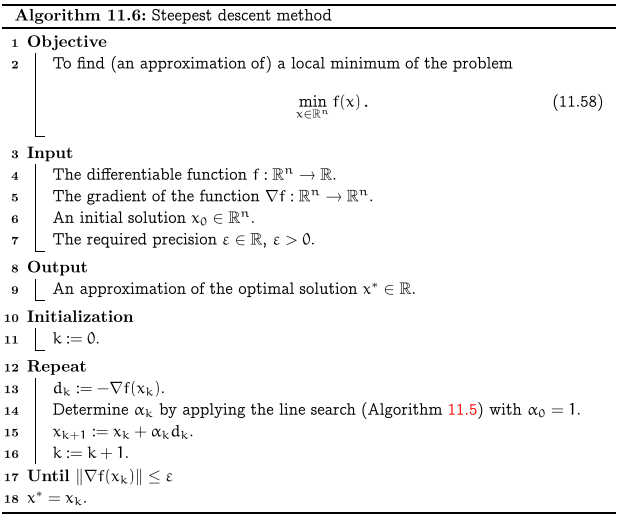

Test in the Rosenbrock function

=== Algoritmo 11.6 — Steepest Descent ===
Função de Rosenbrock, n=2, x₀ = [-1.0, 1.0]

k 		 ||∇f(xk)|| 		 f(xk)
0 		 +4.00000000E+00 		 +4.00000000E+00
1 		 +0.00000000E+00 		 +0.00000000E+00
⋮
1 		 +0.00000000E+00 		 +0.00000000E+00

=== Resultado ===
x*     = [1.0, 1.0]
f(x*)  = 0.0
Iters  = 1
Solução esperada: x* = [1, 1],  f(x*) = 0


┌ Warning: No strict ticks found
└ @ PlotUtils C:\Users\leite\.julia\packages\PlotUtils\HX80C\src\ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils C:\Users\leite\.julia\packages\PlotUtils\HX80C\src\ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils C:\Users\leite\.julia\packages\PlotUtils\HX80C\src\ticks.jl:194
┌ Warning: Invalid negative or zero value 0.0 found at series index 2 for log10 based yscale
└ @ Plots C:\Users\leite\.julia\packages\Plots\GIume\src\utils.jl:105
┌ Warning: No strict ticks found
└ @ PlotUtils C:\Users\leite\.julia\packages\PlotUtils\HX80C\src\ticks.jl:194
┌ Warning: Invalid negative or zero value 0.0 found at series index 2 for log10 based yscale
└ @ Plots C:\Users\leite\.julia\packages\Plots\GIume\src\utils.jl:105
┌ Warning: No strict ticks found
└ @ PlotUtils C:\Users\leite\.julia\packages\PlotUtils\HX80C\src\ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils C:\Users\leite\.julia\packages\PlotUtils\HX80C\src\ticks.jl:194
┌ Warnin

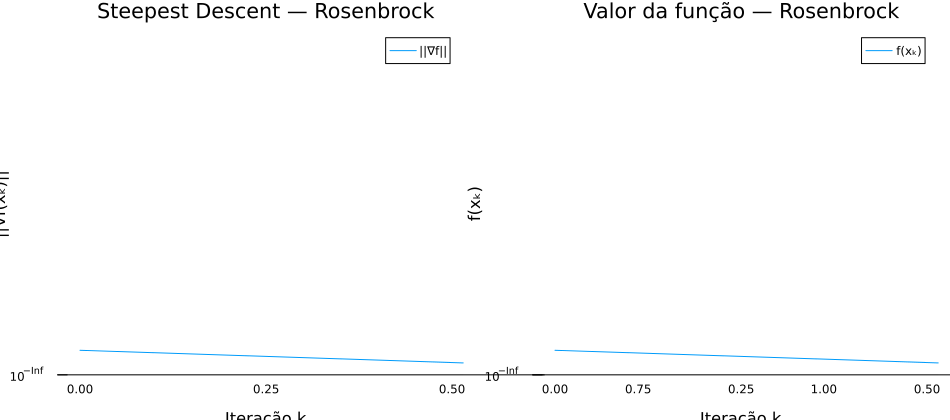

In [20]:
# Algoritmo 11.6 - Steepest Descent com Line Search (Alg. 11.5)
# Testado na função de Rosenbrock (n variáveis)

using LinearAlgebra
using Printf
using Plots

# ── Rosenbrock ────────────────────────────────────────────────────────────
function f(x)
    n = length(x)
    return sum(100*(x[i+1] - x[i]^2)^2 + (1 - x[i])^2 for i in 1:n-1)
end

function ∇f(x)
    n = length(x)
    g = zeros(n)
    for i in 1:n-1
        g[i]   += -400*x[i]*(x[i+1] - x[i]^2) - 2*(1 - x[i])
        g[i+1] +=  200*(x[i+1] - x[i]^2)
    end
    return g
end

# ── Algoritmo 11.5 — Line Search (Wolfe) ─────────────────────────────────
function line_search(f, ∇f, x, d; α₀=1.0, β₁=1e-4, β₂=0.99, λ=2.0)
    slope = ∇f(x)' * d
    slope >= 0 && error("d não é direção de descida")

    αl = 0.0
    αr = Inf
    α  = α₀
    fx = f(x)

    for _ in 1:200
        armijo    = f(x + α*d) <= fx + β₁*α*slope
        curvatura = ∇f(x + α*d)'*d >= β₂*slope

        if armijo && curvatura
            return α
        elseif !armijo
            αr = α
            α  = (αl + αr) / 2.0
        else
            αl = α
            α  = αr < Inf ? (αl + αr) / 2.0 : λ*α
        end
    end
    return α
end

# ── Algoritmo 11.6 — Steepest Descent ────────────────────────────────────
function steepest_descent(f, ∇f, x₀; ε=1e-6, maxiter=10000)
    x  = copy(x₀)
    k  = 0
    n  = length(x)

    ks    = Int[]
    norms = Float64[]
    fvals = Float64[]

    println("k \t\t ||∇f(xk)|| \t\t f(xk)")
    push!(ks, k); push!(norms, norm(∇f(x))); push!(fvals, f(x))
    @printf("%d \t\t %+.8E \t\t %+.8E\n", k, norm(∇f(x)), f(x))

    while norm(∇f(x)) >= ε && k < maxiter

        # Passo 13: direção de máxima descida
        d  = -∇f(x)

        # Passo 14: tamanho do passo via Wolfe (Alg. 11.5)
        αk = line_search(f, ∇f, x, d)

        # Passo 15: atualizar iterado
        x  = x + αk * d
        k += 1

        push!(ks, k); push!(norms, norm(∇f(x))); push!(fvals, f(x))

        # Imprimir a cada 500 iterações + primeiras 10
        if k <= 10 || k % 500 == 0
            @printf("%d \t\t %+.8E \t\t %+.8E\n", k, norm(∇f(x)), f(x))
        end
    end

    return x, k, ks, norms, fvals
end

# ── Teste ─────────────────────────────────────────────────────────────────
n  = 2
x₀ = [-1.0, 1.0]    # ponto inicial clássico para Rosenbrock

println("=== Algoritmo 11.6 — Steepest Descent ===")
println("Função de Rosenbrock, n=$n, x₀ = $x₀\n")

x_star, iters, ks, norms, fvals = steepest_descent(f, ∇f, x₀, ε=1e-6)

println("⋮")
@printf("%d \t\t %+.8E \t\t %+.8E\n", iters, norm(∇f(x_star)), f(x_star))
println("\n=== Resultado ===")
println("x*     = ", round.(x_star, digits=8))
println("f(x*)  = ", f(x_star))
println("Iters  = ", iters)
println("Solução esperada: x* = [1, 1],  f(x*) = 0")

# ── Gráficos ──────────────────────────────────────────────────────────────
p1 = plot(ks, norms,
    seriestype = :line,
    xlabel     = "Iteração k",
    ylabel     = "||∇f(xₖ)||",
    title      = "Steepest Descent — Rosenbrock",
    yscale     = :log10,
    yformatter = :scientific,
    label      = "||∇f||",
    legend     = :topright)

p2 = plot(ks, fvals,
    seriestype = :line,
    xlabel     = "Iteração k",
    ylabel     = "f(xₖ)",
    title      = "Valor da função — Rosenbrock",
    yscale     = :log10,
    yformatter = :scientific,
    label      = "f(xₖ)",
    legend     = :topright)

plot(p1, p2, layout=(1,2), size=(950, 420))